# Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import numpy as np

# Check TensorFlow version
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# Load MNIST Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Images Shape  :", X_test.shape)
print("Testing Labels Shape  :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


# Normalize the Data

In [3]:
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

# One-Hot Encoding

In [4]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

print("Encoded Label Shape:", y_train_cat.shape)

Encoded Label Shape: (60000, 10)


# Define ANN Model

In [5]:
model = Sequential([

    # Flatten 28x28 image → 784 vector
    Flatten(input_shape=(28, 28)),

    # Hidden Layer 1
    Dense(128, activation='relu'),

    # Hidden Layer 2
    Dense(64, activation='relu'),

    # Output Layer
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Compile the Model

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Model

In [8]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9221 - loss: 0.2726 - val_accuracy: 0.9568 - val_loss: 0.1455
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9647 - loss: 0.1139 - val_accuracy: 0.9660 - val_loss: 0.1146
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9754 - loss: 0.0802 - val_accuracy: 0.9732 - val_loss: 0.0973
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9816 - loss: 0.0575 - val_accuracy: 0.9697 - val_loss: 0.0978
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9849 - loss: 0.0466 - val_accuracy: 0.9718 - val_loss: 0.1028
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9878 - loss: 0.0377 - val_accuracy: 0.9737 - val_loss: 0.0939
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9904 - loss: 0.0310 - val_accuracy: 0.9721 - val_loss: 0.1073
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9921 - loss: 0.0242 -

#  Evaluate on Test Data

In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)

print("\nTest Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9760 - loss: 0.1042

Test Loss     : 0.10419639945030212
Test Accuracy : 0.9760000109672546


# Plot Accuracy

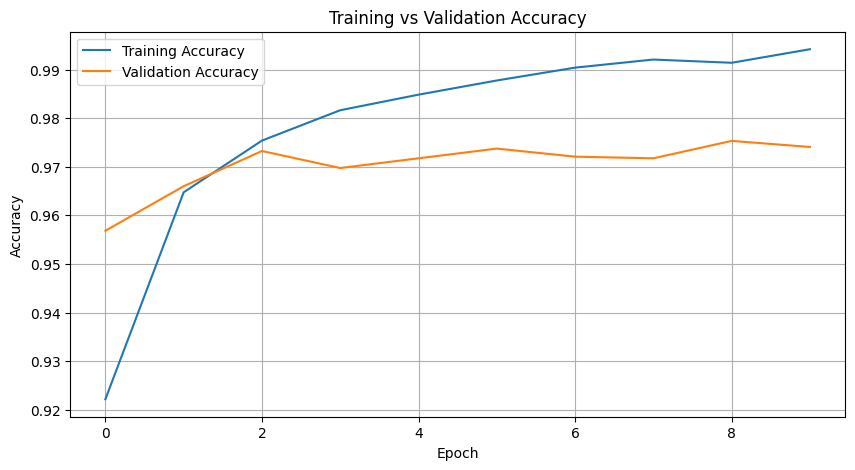

In [10]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# Plot Loss

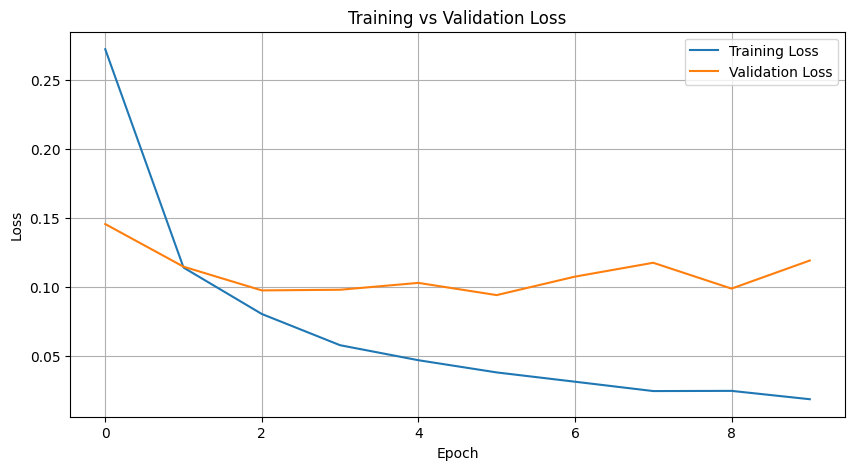

In [11]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# Predictions

In [12]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


# Visualize Predictions

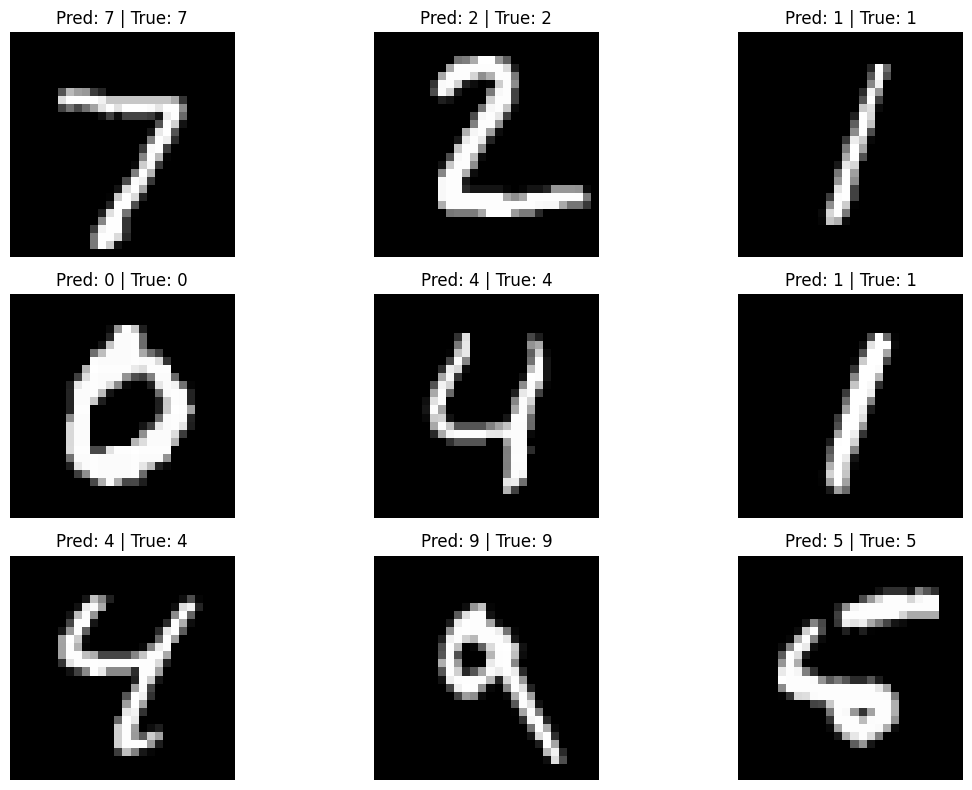

In [13]:
plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i], cmap='gray')

    plt.title(f"Pred: {predicted_labels[i]} | True: {y_test[i]}")

    plt.axis('off')

plt.tight_layout()
plt.show()

# Hyperparameter Tuning

In [14]:
learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [32, 64, 128]

results = []

for lr in learning_rates:

    for batch in batch_sizes:

        print(f"\nTraining with LR={lr}, Batch Size={batch}")

        model_tune = Sequential([
            Flatten(input_shape=(28,28)),
            Dense(128, activation='relu'),
            Dense(64, activation='relu'),
            Dense(10, activation='softmax')
        ])

        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

        model_tune.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history_tune = model_tune.fit(
            X_train,
            y_train_cat,
            epochs=5,
            batch_size=batch,
            validation_split=0.2,
            verbose=0
        )

        loss, acc = model_tune.evaluate(X_test, y_test_cat, verbose=0)

        results.append({
            "Learning Rate": lr,
            "Batch Size": batch,
            "Test Accuracy": acc,
            "Test Loss": loss
        })


Training with LR=0.01, Batch Size=32

Training with LR=0.01, Batch Size=64

Training with LR=0.01, Batch Size=128

Training with LR=0.001, Batch Size=32

Training with LR=0.001, Batch Size=64

Training with LR=0.001, Batch Size=128

Training with LR=0.0001, Batch Size=32

Training with LR=0.0001, Batch Size=64

Training with LR=0.0001, Batch Size=128


# Print Tuning Results

In [15]:
print("\nHyperparameter Tuning Results\n")

for result in results:
    print(result)


Hyperparameter Tuning Results

{'Learning Rate': 0.01, 'Batch Size': 32, 'Test Accuracy': 0.9472000002861023, 'Test Loss': 0.2118993103504181}
{'Learning Rate': 0.01, 'Batch Size': 64, 'Test Accuracy': 0.9628999829292297, 'Test Loss': 0.1463031768798828}
{'Learning Rate': 0.01, 'Batch Size': 128, 'Test Accuracy': 0.9653000235557556, 'Test Loss': 0.1202494278550148}
{'Learning Rate': 0.001, 'Batch Size': 32, 'Test Accuracy': 0.975600004196167, 'Test Loss': 0.08358442038297653}
{'Learning Rate': 0.001, 'Batch Size': 64, 'Test Accuracy': 0.9751999974250793, 'Test Loss': 0.08095379918813705}
{'Learning Rate': 0.001, 'Batch Size': 128, 'Test Accuracy': 0.9750999808311462, 'Test Loss': 0.08254547417163849}
{'Learning Rate': 0.0001, 'Batch Size': 32, 'Test Accuracy': 0.9578999876976013, 'Test Loss': 0.14373840391635895}
{'Learning Rate': 0.0001, 'Batch Size': 64, 'Test Accuracy': 0.9474999904632568, 'Test Loss': 0.18471960723400116}
{'Learning Rate': 0.0001, 'Batch Size': 128, 'Test Accuracy

# Save Model

In [16]:
model.save("mnist_ann_model.h5")

print("\nModel Saved Successfully!")


Model Saved Successfully!
